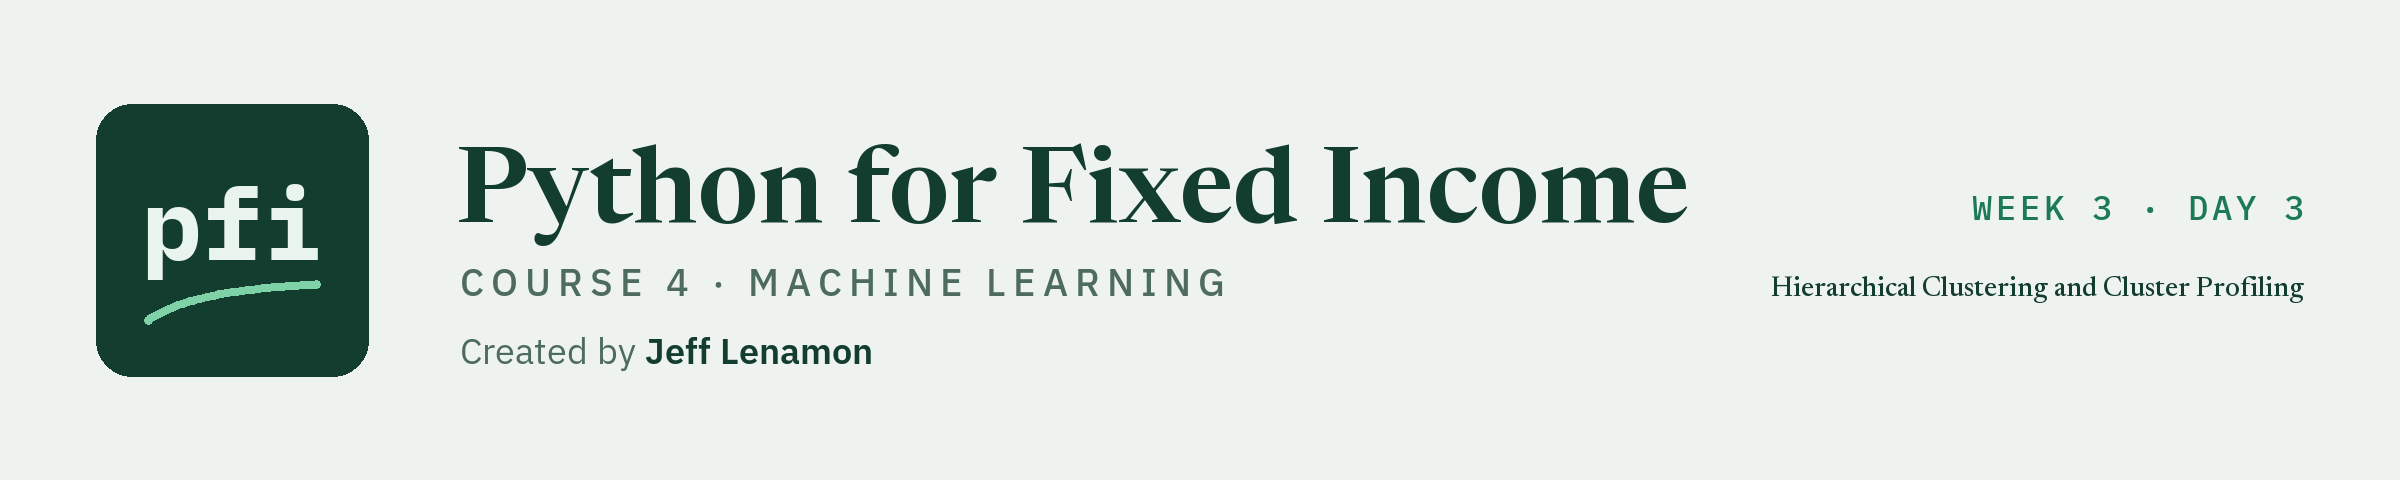

# Hierarchical Clustering and Cluster Profiling

Week 3, Day 3. Hierarchical clustering builds groups from the bottom up and draws every step as a tree. Today: one row per issuer, the distance between two issuers by hand, merges step by step, four linkages, the dendrogram and where to cut it, and a profile of each cluster in the data's own units.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week3/day3/13_hierarchical_clustering_and_cluster_profiling.ipynb)

Yesterday K-means put the 821 bonds into four clusters: you chose k first, and the algorithm moved four centres until the bonds settled. Today the rows are **issuers**, one row for each of the 150 issuers, and the method works the other way round. It starts with every issuer as a cluster of its own, joins the two closest, then the next two closest, and keeps going until one cluster holds them all. Every merge is kept, so you see the whole tree first and choose the number of clusters afterwards, by where you cut it.

Then comes the step that makes clusters useful on a desk: a **profile**, a table of counts and medians for each cluster, in bp, years, and billions of dollars rather than in the scaled units the clusters were built from.

**The data is synthetic.** The bonds of `benchmark.csv` and the issuers of `issuers.csv` are invented, and the spreads were generated by the course's own script, `tools/make_holdings.py`, from each bond's rating, its maturity, an effect shared by each issuer's bonds, and random noise. The number of bonds each issuer has and their sizes are random draws in the same script. A cluster here is a group of similar rows in an invented dataset: never a recommendation, a ranking, or a verdict on any issuer.

Today you will:

1. Build one row per issuer from the bond data, and scale its five columns.
2. Measure the distance between two issuers by hand, and find the closest pair of all.
3. Read the merges one by one, as scipy records them.
4. Compare four linkages: single, complete, average, and ward.
5. Read a dendrogram of 150 issuers, and choose where to cut it.
6. Measure how faithfully the tree keeps the distances: the cophenetic correlation.
7. Cut the tree into clusters with `fcluster`, and profile them with a new function, `cluster_profile`.
8. Compare K-means and hierarchical clusters on the same issuers, and say what a profile may and may not say.

Q. Set up today's work folder: the thread settings, the seed, the data files the tests read, and a fresh work folder.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_13_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "issuers.csv", "course4_excel_reference.csv", "credit_card_default.csv", "treasury_par_yields.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_13_czwbl3do, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, issuers.csv, course4_excel_reference.csv, credit_card_default.csv, treasury_par_yields.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, because statsmodels refuses booleans. The reference is named by the caller,
    never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")


from sklearn.exceptions import NotFittedError
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


def fitted_models() -> tuple[dict, pd.DataFrame, pd.Series]:
    """A scaled logistic regression and a depth-3 balanced tree fitted on the card training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    models = {
        "logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "tree": DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models, X_valid, y_valid


def test_compare_models_columns():
    models, X_valid, y_valid = fitted_models()
    table = mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    assert list(table.index) == ["logistic", "tree"]
    assert list(table.columns) == ["roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall",
                                   "f1"]
    proba = models["logistic"].predict_proba(X_valid)[:, 1]
    assert table.loc["logistic", "roc_auc"] == pytest.approx(roc_auc_score(y_valid, proba), abs=1e-12)
    assert table.loc["logistic", "average_precision"] == pytest.approx(average_precision_score(y_valid, proba),
                                                                         abs=1e-12)
    flags = (proba >= 0.2).astype(int)
    assert table.loc["logistic", "recall"] == pytest.approx(recall_score(y_valid, flags), abs=1e-12)
    with pytest.raises(ValueError, match="tree"):
        mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2})


def test_compare_models_does_not_refit():
    models, X_valid, y_valid = fitted_models()
    before = models["logistic"]["model"].coef_.copy()
    mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    # the coefficients learned on the training rows are untouched
    assert np.array_equal(models["logistic"]["model"].coef_, before)
    # and a model nobody fitted is refused, not fitted on the rows given
    with pytest.raises(NotFittedError):
        mlkit.compare_models({"new": LogisticRegression()}, X_valid, y_valid, {"new": 0.5})


def test_assert_descriptive_passes_plain_text():
    mlkit.assert_descriptive("In this file the model ranked 72 percent of default and non-default pairs correctly. "
                             "A willing reader can check every number.")


def test_assert_descriptive_names_the_word():
    with pytest.raises(ValueError, match=r"\['will', 'cheap'\]"):
        mlkit.assert_descriptive("These bonds look Cheap and spreads WILL tighten.")


from sklearn.model_selection import TimeSeriesSplit


def treasury_dates() -> pd.DatetimeIndex:
    """The 2,940 dates of the Treasury par yield file, 2015-01-02 to 2026-10-02."""
    return pd.DatetimeIndex(pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"])["date"])


def test_walk_forward_hand_index():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2)
    expected = [([0, 1, 2, 3], [4, 5]), ([0, 1, 2, 3, 4, 5], [6, 7]), ([0, 1, 2, 3, 4, 5, 6, 7], [8, 9])]
    assert [(train.tolist(), test.tolist()) for train, test in splits] == expected
    # a last window of one row is dropped
    assert len(mlkit.walk_forward_splits(dates[:9], min_train=4, test_size=2)) == 2


def test_walk_forward_gap():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2, gap=1)
    assert [(train.tolist(), test.tolist()) for train, test in splits] == [
        ([0, 1, 2, 3], [5, 6]), ([0, 1, 2, 3, 4, 5], [7, 8])]
    for train, test in splits:
        mlkit.assert_past_only(dates[train], dates[test], gap=1, calendar=dates)
    # scikit-learn's TimeSeriesSplit with the same test size and gap gives the same positions
    ours = mlkit.walk_forward_splits(dates, min_train=5, test_size=2, gap=1)
    library = TimeSeriesSplit(n_splits=2, test_size=2, gap=1).split(np.zeros(len(dates)))
    assert [(a.tolist(), b.tolist()) for a, b in ours] == [(a.tolist(), b.tolist()) for a, b in library]


def test_walk_forward_past_only():
    dates = treasury_dates()
    # about two years to start, about six months per test window
    splits = mlkit.walk_forward_splits(dates, min_train=504, test_size=126)
    assert len(splits) == (len(dates) - 504) // 126
    for train, test in splits:
        mlkit.assert_disjoint(train, test)
        mlkit.assert_past_only(dates[train], dates[test])
        assert len(test) == 126


def test_walk_forward_rejects_unsorted():
    dates = pd.DatetimeIndex(["2026-01-06", "2026-01-05", "2026-01-07", "2026-01-08"])
    with pytest.raises(ValueError, match="ascending"):
        mlkit.walk_forward_splits(dates, min_train=2, test_size=1)
    with pytest.raises(ValueError, match="unique"):
        mlkit.walk_forward_splits(pd.DatetimeIndex(["2026-01-05"] * 4), min_train=2, test_size=1)


def test_assert_past_only_raises():
    dates = treasury_dates()
    # a shuffled split puts later dates in training: it is refused
    shuffled = KFold(5, shuffle=True, random_state=SEED)
    train, test = next(shuffled.split(np.zeros(len(dates))))
    with pytest.raises(AssertionError, match="not before"):
        mlkit.assert_past_only(dates[train], dates[test])
    # a gap of 5 rows asked for, 0 given
    with pytest.raises(AssertionError, match="gap of 5"):
        mlkit.assert_past_only(dates[:100], dates[100:110], gap=5, calendar=dates)
    with pytest.raises(ValueError, match="calendar"):
        mlkit.assert_past_only(dates[:100], dates[105:110], gap=5)


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def scaled_bonds() -> np.ndarray:
    """log_oas, duration, coupon, and rating score of the 821 bonds, each scaled to mean 0 and standard deviation 1
    (StandardScaler, fitted on every bond: nothing is tested on held-out rows when clustering)."""
    bench = read_bench()
    return StandardScaler().fit_transform(bench[["log_oas", "duration", "coupon", "score"]])


def test_elbow_table_columns_and_ks():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert list(table.index) == list(range(2, 9))
    assert table.index.name == "k"
    assert list(table.columns) == ["inertia", "silhouette"]
    assert table["silhouette"].between(-1, 1).all()
    with pytest.raises(ValueError):
        mlkit.elbow_table(scaled_bonds(), [1, 3])


def test_elbow_inertia_decreases():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert table["inertia"].is_monotonic_decreasing


def test_elbow_matches_kmeans():
    X = scaled_bonds()
    table = mlkit.elbow_table(X, [4])
    model = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X)
    assert table.loc[4, "inertia"] == pytest.approx(model.inertia_, abs=1e-9)
    assert table.loc[4, "silhouette"] == pytest.approx(silhouette_score(X, model.labels_), abs=1e-12)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds', 'compare_models', 'assert_descriptive', 'walk_forward_splits', 'assert_past_only', 'elbow_table']


* The setup wrote `mlkit.py` and `test_mlkit.py` as they stood at the end of day 12, so this notebook runs even if you skipped a day. Today adds one function, `cluster_profile`, and its three tests in section 13.6.
* Today copies one more file than the tests need: `issuers.csv`, the list of the 150 invented issuers with each one's rating.
* Hierarchical clustering makes no random choice at all: the same rows give the same tree on every run, with no seed. `SEED` is still used today, by the K-means of section 13.7.

## 13.1 Building Clusters from the Bottom

Hierarchical clustering, in the bottom-up form used here (**agglomerative**), has three steps:

1. Start with every row as a cluster of one.
2. Join the two clusters that are closest.
3. Repeat until one cluster is left, and record every join.

With n rows that is n - 1 joins. Nothing is chosen before it starts: no k, no starting centres, no seed.

Q. Load the bonds, with each one's log OAS.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [5]:
import matplotlib.pyplot as plt

# the 821 synthetic benchmark bonds, the rating table, and the list of the invented issuers
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
issuer_list = pd.read_csv("issuers.csv")

# log OAS: the natural log of the spread in bp, as days 4, 5, and 12 used it
bench["log_oas"] = np.log(bench["oas"])
print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers; issuers.csv lists {len(issuer_list)}")

821 bonds of 150 invented issuers; issuers.csv lists 150


* 821 bonds and 150 issuers, every one of them invented.

Q. Build one row per issuer: the median log OAS, the median duration, the number of bonds, and the total amount outstanding.

`groupby("ticker")` collects each issuer's bonds; `agg` computes one number per column for each group. The median, not the mean, so that one unusual bond does not move its issuer's row much.

In [6]:
# one row per issuer, from its bonds
issuers = bench.groupby("ticker").agg(
    median_oas=("oas", "median"),                # bp
    median_log_oas=("log_oas", "median"),        # natural log of bp
    median_duration=("duration", "median"),      # years
    bonds=("cusip", "size"),                     # how many bonds the issuer has in the file
    amount_bn=("amount_outstanding", "sum"),     # dollars, turned into billions on the next line
)
issuers["amount_bn"] = issuers["amount_bn"] / 1e9   # total amount outstanding, USD billions

# each issuer's name, sector, and rating from issuers.csv; validate= stops if a ticker appears twice on either side
issuers = issuers.join(issuer_list.set_index("ticker")[["issuer", "sector", "rating"]], validate="one_to_one")
# the rating score, 1 (AAA) to 18 (CCC), from ratings.csv
issuers["score"] = issuers["rating"].map(ratings.set_index("rating")["score"])
assert issuers["score"].notna().all(), "an issuer has a rating that ratings.csv does not list"

print(f"{len(issuers)} issuers, one row each, {issuers.shape[1]} columns")
issuers.head()

150 issuers, one row each, 9 columns


,median_oas,median_log_oas,median_duration,bonds,amount_bn,issuer,sector,rating,score
ticker,,,,,,,,,
BEZE,183.0,5.209113,6.7490,6,9.3,Bezane Finance,Financials,BBB-,10
BEZH,372.0,5.918894,5.1000,5,9.4,Bezamyth Machinery,Industrials,B,15
BEZL,194.0,5.267858,5.4290,7,7.5,Bezoquil Freight,Transportation,BB,12
BEZN,152.0,5.023881,7.3380,5,6.0,Bezorin Finance,Financials,BBB-,10
BEZR,82.5,4.412339,3.3285,6,9.4,Bezimer Power,Utilities,A,6


* 150 rows, one per invented issuer, in ticker order. `median_oas` stays in the table in bp for the profile; the clusters use `median_log_oas`, because days 4 and 12 showed that the log keeps a few very wide spreads from deciding everything.

Q. Does every bond carry its issuer's rating, so that one rating score per issuer is the right summary?

In [7]:
# each bond's rating beside its issuer's rating in issuers.csv
check_ratings = bench.merge(issuer_list[["ticker", "rating"]], on="ticker", suffixes=("", "_issuer"), validate="many_to_one")
print(f"bonds whose rating differs from their issuer's: {(check_ratings['rating'] != check_ratings['rating_issuer']).sum()}")
print(f"issuers with more than one rating among their bonds: {(bench.groupby('ticker')['rating'].nunique() > 1).sum()}")

bonds whose rating differs from their issuer's: 0
issuers with more than one rating among their bonds: 0


* None. In this file every bond has its issuer's rating, so the score in `issuers.csv` is each issuer's score. In real data an issuer's bonds can carry different ratings (a secured bond and a subordinated one), and the table would need a rule for that.

Q. How different are the five columns' units?

In [8]:
# the five columns the clusters are built from
features = ["median_log_oas", "median_duration", "bonds", "amount_bn", "score"]
issuers[features].agg(["mean", "std", "min", "max"]).T.round(2)

,mean,std,min,max
median_log_oas,4.88,0.71,3.04,6.83
median_duration,5.85,1.93,1.02,13.07
bonds,5.47,1.74,3.00,8.00
amount_bn,7.62,2.79,1.70,15.00
score,9.21,3.53,1.00,18.00


* Bonds per issuer run from 3 to 8, the amount from 1.70 to 15.00 billion dollars, the score from 1 to 18. Day 12 showed what unscaled columns do to a distance: the one with the biggest numbers decides it. So the five columns are scaled first.

Q. Scale the five columns to mean 0 and standard deviation 1.

As on day 12, the scaler is fitted on every row, because nothing is reported on rows held back: there are no test rows in clustering. If clusters ever fed a supervised model, the scaler would go inside its pipeline and be fitted on training rows only.

In [9]:
from sklearn.preprocessing import StandardScaler

# StandardScaler: (x - mean) / population standard deviation, column by column, fitted on all 150 issuers
X_scaled = StandardScaler().fit_transform(issuers[features])
scaled = pd.DataFrame(X_scaled, columns=features, index=issuers.index)

print(f"means all 0 within 1e-12: {(scaled.mean().abs() < 1e-12).all()}")
print(f"population standard deviations all 1 within 1e-12: {((scaled.std(ddof=0) - 1).abs() < 1e-12).all()}")
scaled.head(3).round(4)

means all 0 within 1e-12: True
population standard deviations all 1 within 1e-12: True


,median_log_oas,median_duration,bonds,amount_bn,score
ticker,,,,,
BEZE,0.4662,0.4674,0.3036,0.6044,0.2236
BEZH,1.4690,-0.3885,-0.2729,0.6403,1.6446
BEZL,0.5492,-0.2177,0.8801,-0.0423,0.7920


* Every column now has mean 0 and standard deviation 1, so a difference of 1 means one standard deviation in any column: about 1.73 bonds, 2.78 billion dollars, 1.93 years of duration, or 3.52 notches.

Q. How far apart are the first two issuers, BEZE and BEZH? Work it by hand.

In [10]:
# the two issuers' scaled rows, the difference in each column, and its square
pair = scaled.loc[["BEZE", "BEZH"]].T
pair["difference"] = pair["BEZH"] - pair["BEZE"]
pair["squared"] = pair["difference"] ** 2
print(pair.round(4))

# Euclidean distance: the square root of the sum of the squared differences
distance_by_hand = np.sqrt(pair["squared"].sum())
print(f"distance between BEZE and BEZH: {distance_by_hand:.4f} standard deviations")

ticker             BEZE    BEZH  difference  squared
median_log_oas   0.4662  1.4690      1.0028   1.0057
median_duration  0.4674 -0.3885     -0.8559   0.7326
bonds            0.3036 -0.2729     -0.5765   0.3323
amount_bn        0.6044  0.6403      0.0359   0.0013
score            0.2236  1.6446      1.4210   2.0192
distance between BEZE and BEZH: 2.0227 standard deviations


* 2.0227. Each column contributes its squared difference, and the largest square decides most of the distance. This is the same Euclidean distance as day 12, now between two issuers.

Q. Does scipy's `pdist` give the same number, and which two issuers are closest of all?

`pdist` computes the distance between every pair of rows: 150 issuers make 11,175 pairs. `squareform` lays them out as a 150 by 150 table.

In [11]:
from scipy.spatial.distance import pdist, squareform

# every pairwise Euclidean distance, as a 150 by 150 table labelled by ticker
distances = pd.DataFrame(squareform(pdist(X_scaled)), index=issuers.index, columns=issuers.index)
print(f"pairs of issuers: {len(pdist(X_scaled)):,}")
print(f"pdist equal to the hand calculation within 1e-12: {abs(distances.iloc[0, 1] - distance_by_hand) < 1e-12}")

# the closest pair: blank out the zeros on the diagonal (an issuer's distance to itself), then find the smallest
off_diagonal = distances.where(~np.eye(len(distances), dtype=bool))
first, second = off_diagonal.stack().idxmin()
print(f"closest pair: {first} and {second}, {off_diagonal.loc[first, second]:.4f} apart")
issuers.loc[[first, second], ["issuer", "rating", "median_oas", "median_duration", "bonds", "amount_bn"]]

pairs of issuers: 11,175
pdist equal to the hand calculation within 1e-12: True
closest pair: CLAY and WYXR, 0.2075 apart


,issuer,rating,median_oas,median_duration,bonds,amount_bn
ticker,,,,,,
CLAY,Clavolvey Bancorp,BB+,221.5,5.611,6,8.60
WYXR,Wyximer Wireless,BB+,197.5,5.580,6,8.25


* The closest pair is CLAY and WYXR, 0.2075 apart: the same rating, nearly the same spread and duration, and similar sizes. These two are the first merge.

Q. Run the whole bottom-up procedure and read its first merges.

`linkage(X, method="ward")` returns one row per merge, 149 rows in all. Each row holds the two clusters joined, the height at which they join, and how many issuers the new cluster holds. Clusters 0 to 149 are the single issuers; the cluster made by row i of the table is numbered 150 + i.

In [12]:
from scipy.cluster.hierarchy import linkage

# ward linkage on the scaled issuers: every merge, from the first to the last
merges = linkage(X_scaled, method="ward")
print(f"merges: {len(merges)}; issuers in the last merge: {int(merges[-1, 3])}")


def member(i):
    """A ticker for clusters 0 to 149 (single issuers), or the number of a cluster formed by an earlier merge."""
    i = int(i)
    return issuers.index[i] if i < len(issuers) else f"cluster {i}"


# the first merges, with tickers in place of row numbers
first_merges = pd.DataFrame({
    "joins": [member(a) for a in merges[:8, 0]],
    "with": [member(b) for b in merges[:8, 1]],
    "height": merges[:8, 2].round(4),
    "issuers": merges[:8, 3].astype(int),
}).rename_axis("merge")
print(first_merges)

# the first merge that joins a cluster formed earlier, not two single issuers
grown = int(np.flatnonzero((merges[:, 0] >= len(issuers)) | (merges[:, 1] >= len(issuers)))[0])
print(f"first merge with a formed cluster: merge {grown}, {member(merges[grown, 0])} with {member(merges[grown, 1])} "
      f"at {merges[grown, 2]:.4f}, making a cluster of {int(merges[grown, 3])}")

merges: 149; issuers in the last merge: 150
      joins  with  height  issuers
merge                             
0      CLAY  WYXR  0.2075        2
1      ELVX  GALY  0.2586        2
2      BEZN  VYRN  0.3289        2
3      THAX  XANH  0.3628        2
4      HESA  KEZA  0.4167        2
5      CLAL  YARN  0.4331        2
6      FESR  NEVN  0.4447        2
7      CLAX  ELVN  0.4491        2
first merge with a formed cluster: merge 42, RULE with cluster 169 at 0.7167, making a cluster of 3


* Merge 0 joins CLAY and WYXR at a height of 0.2075, exactly their distance. The first 42 merges all pair two single issuers. Merge 42 is the first that joins a cluster already formed: RULE with cluster 169 at 0.7167; cluster 169 is the one made by merge 19.
* For ward linkage scipy reports the height so that two single issuers join at their distance. When a cluster has more than one member, the height grows with how much the merge adds to the spread of issuers around their cluster's centre, so later merges sit higher.

## 13.2 Linkages: Single, Complete, Average, Ward

Between two single issuers, distance is plain. Between two clusters it needs a rule, the **linkage**:

| Linkage | Distance between two clusters | Tends to |
| --- | --- | --- |
| single | the closest pair, one issuer from each | chain: join clusters through one near pair, and leave one large cluster |
| complete | the farthest pair | make compact clusters of similar width |
| average | the average over all pairs | sit between single and complete |
| ward | how much the merge increases the squared distances of issuers from their cluster's centre | make compact clusters of similar size, like K-means |

The course uses Euclidean distance on scaled columns with all four, and ward as its default.

Q. Run all four linkages, cut each tree into 4 clusters, and compare the sizes.

In [13]:
from scipy.cluster.hierarchy import fcluster


def number_by_size(labels):
    """Renumber cluster labels by cluster size, largest first, so cluster 0 is the largest (day 12's rule).

    Two clusters of the same size are ordered by which one holds the earlier row of the table (here, the
    earlier ticker). A label carries no meaning beyond the group it names, and neither rule depends on how
    an algorithm happened to number its clusters.
    """
    labels = pd.Series(labels)
    # how many rows each label holds, and the position of the first row with each label
    sizes = labels.value_counts()
    first_seen = {label: position for position, label in enumerate(pd.unique(labels))}
    # largest first; a tie goes to the cluster seen first
    order = sorted(sizes.index, key=lambda label: (-sizes[label], first_seen[label]))
    renumber = {old: new for new, old in enumerate(order)}
    return labels.map(renumber).to_numpy()


trees = {}
size_rows = {}
for method in ["single", "complete", "average", "ward"]:
    # the full tree for this linkage, then cut into 4 clusters
    trees[method] = linkage(X_scaled, method=method)
    cut = fcluster(trees[method], t=4, criterion="maxclust")
    # the four cluster sizes, largest first (two clusters can have the same size here, so no numbering yet)
    size_rows[method] = sorted(pd.Series(cut).value_counts().tolist(), reverse=True)

pd.DataFrame(size_rows, index=["largest", "second", "third", "smallest"]).T.rename_axis("linkage")

,largest,second,third,smallest
linkage,,,,
single,145,2,2,1
complete,64,35,28,23
average,115,30,3,2
ward,68,35,24,23


* Single linkage leaves 145 of 150 issuers in one cluster and 2, 2, 1 in the others: it joins clusters through their nearest members, so a chain of similar issuers ends up as one long group, and the stragglers stay on their own. Average linkage leaves 115. Complete (64, 35, 28, 23) and ward (68, 35, 24, 23) give groups of more even size.
* None of these is the right answer. Each linkage is a different definition of "close" for groups, and each gives a different tree from the same distances.

Q. Draw the top of each tree side by side.

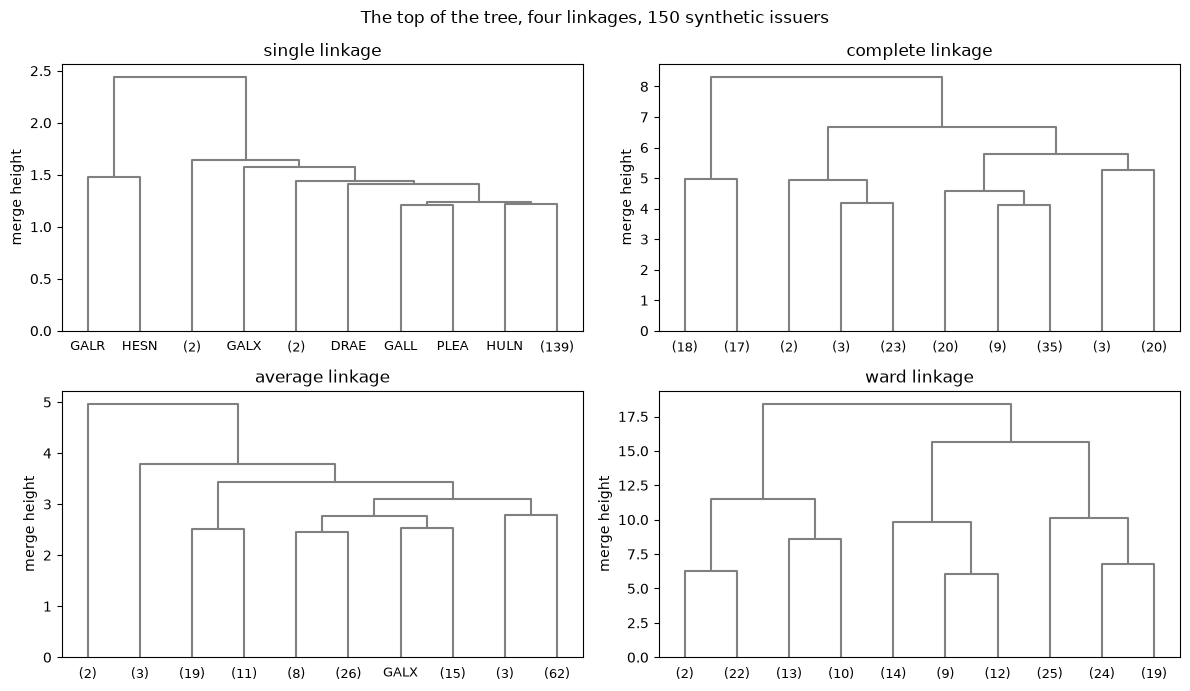

In [14]:
from scipy.cluster.hierarchy import dendrogram

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, method in zip(axes.flat, ["single", "complete", "average", "ward"]):
    # the last 10 merges only: each leaf at the bottom is a cluster, labelled with its number of issuers in brackets
    dendrogram(trees[method], ax=ax, truncate_mode="lastp", p=10, labels=issuers.index.tolist(),
               leaf_font_size=9, color_threshold=0, above_threshold_color="grey")
    ax.set_title(f"{method} linkage")
    ax.set_ylabel("merge height")
fig.suptitle("The top of the tree, four linkages, 150 synthetic issuers")
fig.tight_layout()
plt.show()

* Each panel shows the last 10 merges; a label like `(68)` is a cluster of 68 issuers whose earlier merges are hidden. Single linkage's tree is long and thin: most of the last merges add one issuer to the big group. Ward's merges climb steeply at the top, a sign of a few well separated groups. The heights are not comparable across panels: each linkage measures them its own way.

## 13.3 The Dendrogram, and Where to Cut

A **dendrogram** draws every merge: the issuers along the bottom, a bracket joining two clusters at the height of their merge. Drawing a horizontal line across it and counting the vertical lines it crosses gives the number of clusters for a cut at that height.

Q. Draw the whole ward tree, all 150 issuers.

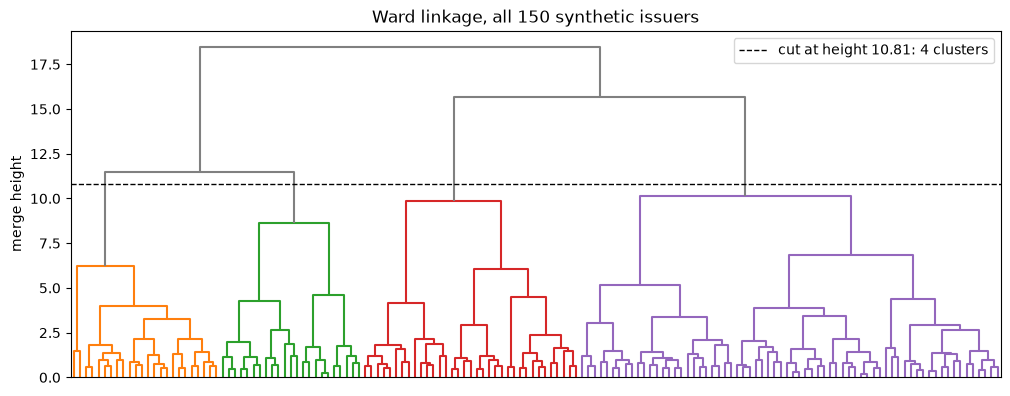

In [15]:
# halfway between the merge that leaves 4 clusters and the merge that leaves 3: a cut there gives 4 clusters
cut_height = (merges[-4, 2] + merges[-3, 2]) / 2

fig, ax = plt.subplots(figsize=(12, 4.5))
# 150 leaves are too many to label, so the leaf labels are left off; colours mark the clusters below the cut
dendrogram(merges, ax=ax, no_labels=True, color_threshold=cut_height, above_threshold_color="grey")
ax.axhline(cut_height, color="black", linestyle="--", linewidth=1, label=f"cut at height {cut_height:.2f}: 4 clusters")
ax.set_title("Ward linkage, all 150 synthetic issuers")
ax.set_ylabel("merge height")
ax.legend()
plt.show()

* With 150 leaves the bottom of the tree is a dense comb: you can see the shape, but not read a ticker. The dashed line at 10.81 crosses four vertical lines, so a cut there gives four clusters, coloured below it.

Q. Draw the top of the same tree, legibly: the last 12 merges, with a count on every leaf.

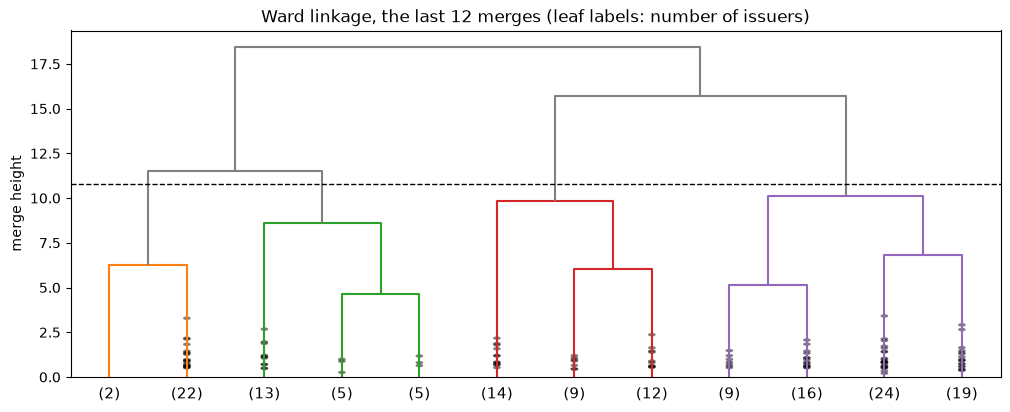

In [16]:
fig, ax = plt.subplots(figsize=(12, 4.5))
# truncate_mode="lastp" keeps the last p merges; a leaf in brackets is a cluster of that many issuers
dendrogram(merges, ax=ax, truncate_mode="lastp", p=12, labels=issuers.index.tolist(), leaf_font_size=11,
           show_contracted=True, color_threshold=cut_height, above_threshold_color="grey")
ax.axhline(cut_height, color="black", linestyle="--", linewidth=1)
ax.set_title("Ward linkage, the last 12 merges (leaf labels: number of issuers)")
ax.set_ylabel("merge height")
plt.show()

* Now every leaf can be read: `(n)` is a cluster of n issuers. The small marks on the stems (`show_contracted`) show heights of merges hidden inside a leaf. This is the version to put on a slide.
* Below the dashed line are four branches. From left to right they hold 24, 23, 35, 68 issuers; after section 13.5 numbers the clusters by size, they are clusters 2, 3, 1, 0. The colours are the dendrogram's own and do not follow the cluster numbers.

Q. How high are the last merges, and where would other cuts fall?

In [17]:
# the last six merges, highest first, and how many clusters a cut just below each one leaves
last_merges = pd.DataFrame({
    "height": merges[-6:, 2][::-1].round(4),
    "clusters if cut just below": range(2, 8),
}).rename_axis("merge from the top")
print(f"cut used today: {cut_height:.4f}")
last_merges

cut used today: 10.8058


,height,clusters if cut just below
merge from the top,,
0,18.4445,2
1,15.6804,3
2,11.4930,4
3,10.1186,5
4,9.8433,6
5,8.6223,7


* The last merge joins everything at 18.4445; the one before it at 15.6804; then 11.4930, 10.1186. A cut anywhere between 10.1186 and 11.4930 gives 4 clusters.
* Two common rules point elsewhere. The longest stretch of height with no merge, read as "the cut that is hardest to move", gives 3 clusters (68, 47, 35). The silhouette of day 12 is highest at k = 2 (0.2270) and is 0.2153 at k = 4. The course cuts at 4, as a judgement: it keeps the comparison with day 12's four clusters, and section 13.6 shows that the fourth cluster splits the low-spread issuers by duration, which a cut at 3 merges. Someone who cut at 3 would have a defensible tree too.

Q. Is the order of the leaves the same every time?

In [18]:
# the order of the leaves along the bottom of the full tree, computed twice
leaf_order = dendrogram(merges, no_plot=True, labels=issuers.index.tolist())["ivl"]
leaf_order_again = dendrogram(linkage(X_scaled, method="ward"), no_plot=True, labels=issuers.index.tolist())["ivl"]
print(f"first 10 leaves: {leaf_order[:10]}")
print(f"same order on a second run: {leaf_order == leaf_order_again}")

first 10 leaves: ['GALR', 'HESN', 'GALN', 'HULR', 'HESR', 'MORN', 'QUEE', 'CORE', 'NEVE', 'JAXN']
same order on a second run: True


* The same 150 tickers in the same order. Hierarchical clustering has no random start, so the tree, its heights, and its leaf order repeat exactly, run after run. A dendrogram's left-to-right order is only a drawing convention, though: two neighbours at the bottom are close in the tree, but the order of the branches could be flipped at every merge without changing anything.

## 13.4 Cophenetic Correlation

A tree replaces 11,175 distances with 149 merge heights. The **cophenetic distance** of two issuers is the height at which the tree first puts them in the same cluster. The **cophenetic correlation** is the correlation between those heights and the original distances, over every pair: near 1, the tree keeps the distances faithfully; lower, it bends them.

Q. What is the cophenetic distance of the closest pair, and of two issuers that only meet in the last merge?

In [19]:
from scipy.cluster.hierarchy import cophenet

# cophenet(tree) returns every pair's cophenetic distance, in pdist's order; squareform lays it out as a table
tree_heights = pd.DataFrame(squareform(cophenet(merges)), index=issuers.index, columns=issuers.index)

print(f"CLAY and WYXR: distance {distances.loc['CLAY', 'WYXR']:.4f}, "
      f"cophenetic {tree_heights.loc['CLAY', 'WYXR']:.4f}")
# the cophenetic distance of the first two issuers in the table
print(f"BEZE and BEZH: distance {distances.loc['BEZE', 'BEZH']:.4f}, cophenetic {tree_heights.loc['BEZE', 'BEZH']:.4f}")

CLAY and WYXR: distance 0.2075, cophenetic 0.2075
BEZE and BEZH: distance 2.0227, cophenetic 15.6804


* The closest pair keeps its distance exactly: they are the first merge. BEZE and BEZH are 2.0227 apart, but the tree only puts them together at 15.6804, the second merge from the top: once two issuers fall on different branches, the tree records them as far apart as those branches are.

Q. Which linkage keeps the distances most faithfully?

In [20]:
# the cophenetic correlation of each linkage's tree with the original distances
cophenetic_table = pd.Series({method: cophenet(trees[method], pdist(X_scaled))[0] for method in trees},
                             name="cophenetic correlation").rename_axis("linkage")
cophenetic_table.round(4)

linkage
single      0.4637
complete    0.4903
average     0.6317
ward        0.5212
Name: cophenetic correlation, dtype: float64

* Average linkage keeps the distances best (0.6317), then ward (0.5212), complete (0.4903), and single (0.4637). Yet average linkage's four clusters were 115, 30, 3, 2 issuers. The cophenetic correlation measures how well the whole tree keeps the distances, not whether a cut through it gives groups you can use. Report it, and look at the cut as well.

## 13.5 Cutting the Tree with `fcluster`

`fcluster` turns a tree into a cluster number for every row. Two ways to cut, which give the same clusters here:

* `criterion="maxclust"`, `t=4`: the highest cut that leaves at most 4 clusters. The course's convention.
* `criterion="distance"`, `t=cut_height`: cut at a height you choose.

Q. Cut the ward tree into 4 clusters both ways, and number the clusters by size.

In [21]:
# the cut by number of clusters, and the cut by height
by_count = fcluster(merges, t=4, criterion="maxclust")
by_height = fcluster(merges, t=cut_height, criterion="distance")
print(f"the same clusters both ways: {(by_count == by_height).all()}")
print(f"fcluster's own numbers: {sorted(int(v) for v in set(by_count))}")

# the course's numbering: by size, largest first
issuers["cluster"] = number_by_size(by_count)
issuers["cluster"].value_counts().sort_index().rename("issuers")

the same clusters both ways: True
fcluster's own numbers: [1, 2, 3, 4]


cluster
0    68
1    35
2    24
3    23
Name: issuers, dtype: int64

* Four clusters of 68, 35, 24, 23 issuers. `fcluster` numbers them 1 to 4 in the order of the tree; the course renumbers them 0 to 3 by size, as on day 12, because a cluster number names a group and nothing more. Cluster 0 is the largest, not the first in any order of quality.

Q. Does scikit-learn's `AgglomerativeClustering` give the same groups?

In [22]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

# the same method in scikit-learn: ward linkage, 4 clusters (it takes no random_state: there is nothing random)
agglomerative = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(X_scaled)
# the adjusted Rand index is 1 when two labellings make the same groups, whatever numbers they use
print(f"adjusted Rand index against fcluster: {adjusted_rand_score(issuers['cluster'], agglomerative.labels_):.4f}")

adjusted Rand index against fcluster: 1.0000


* 1.0000: the same four groups. scipy gives you the whole tree to draw and cut; scikit-learn gives you the labels in its usual build and fit pattern. Use scipy to look, and either to label.

## 13.6 Profiling in the Data's Own Units

A cluster number is not a description. The **profile** is: for each cluster, how many rows it holds, and a typical value of each column. The typical value is the median, so that one wide issuer does not pull it, and it is in the data's **own units**: OAS in bp, duration in years, the amount in billions of dollars. The scaled units the clusters were built from mean nothing on a desk: a median of 0.8 standard deviations of log OAS is not a spread.

Q. Add `cluster_profile` to `mlkit.py`, docstring first.

In [23]:
%%writefile -a mlkit.py


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()

Appending to mlkit.py


* The docstring says which frame to pass: the rows **in their original units**, not the scaled features. The function checks that the labels and the rows line up, and names any column it cannot find.
* A pivot table can count and average, but cannot give a median; the docstring says what Excel does instead. The Excel section shows it.

Q. Add the three tests: hand values, the original units, and a length that does not match.

In [24]:
%%writefile -a test_mlkit.py


def test_cluster_profile_counts():
    frame = pd.DataFrame({"oas": [100.0, 120.0, 400.0, 500.0, 600.0]})
    profile = mlkit.cluster_profile(frame, [0, 0, 1, 1, 1], ["oas"])
    assert profile.index.name == "cluster"
    assert profile["count"].tolist() == [2, 3]
    assert profile["oas"].tolist() == [110.0, 500.0]


def test_cluster_profile_original_units():
    bench = read_bench()
    labels = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(scaled_bonds()).labels_
    profile = mlkit.cluster_profile(bench, labels, ["oas", "duration"])
    assert profile["count"].sum() == len(bench)
    for k in profile.index:
        # medians in bp and years, from the unscaled rows
        assert profile.loc[k, "oas"] == bench.loc[labels == k, "oas"].median()
        assert profile.loc[k, "duration"] == bench.loc[labels == k, "duration"].median()
    # in bp, not in scaled units: every median spread is a positive number of bp
    assert (profile["oas"] > 10).all()


def test_cluster_profile_length_mismatch_raises():
    frame = pd.DataFrame({"oas": [100.0, 120.0, 400.0]})
    with pytest.raises(ValueError, match="labels has 2 values"):
        mlkit.cluster_profile(frame, [0, 1], ["oas"])
    with pytest.raises(ValueError, match="duration"):
        mlkit.cluster_profile(frame, [0, 1, 1], ["duration"])

Appending to test_mlkit.py


* `test_cluster_profile_original_units` clusters the bonds as day 12 did and checks that every median equals the median of the unscaled rows in bp and years, and that every median spread is a positive number of bp, which no scaled column could be.

Q. Reload the module and run all the tests.

In [25]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"cluster_profile in mlkit: {hasattr(mlkit, 'cluster_profile')}")

cluster_profile in mlkit: True


In [26]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.....................................................                    [100%]
53 passed in 5.45s



* `53 passed`: day 12's 50 and today's 3.

Q. Profile the four clusters: count, then the median of each column in its own units.

In [27]:
# the profile columns, in their own units: OAS in bp, duration in years, bonds, USD billions, rating score
profile_columns = ["median_oas", "median_duration", "bonds", "amount_bn", "score"]
profile = mlkit.cluster_profile(issuers, issuers["cluster"], profile_columns)
profile.round(2)

,count,median_oas,median_duration,bonds,amount_bn,score
cluster,,,,,,
0,68,124.5,6.48,7.0,8.70,9.0
1,35,342.0,5.23,4.0,6.05,14.0
2,24,68.0,7.32,3.5,4.03,5.0
3,23,73.0,3.57,5.0,7.50,6.0


Read each row as a description of a group of invented issuers:

* **Cluster 0** (68 issuers): median OAS 124.5 bp, duration 6.48 years, 7 bonds and 8.70 billion dollars outstanding, median score 9. The largest group, and the issuers with the most bonds.
* **Cluster 1** (35 issuers): median OAS 342 bp and median score 14, the widest spreads and lowest ratings in the file.
* **Cluster 2** (24 issuers): median OAS 68 bp, score 5, the longest median duration, 7.32 years, and the fewest bonds (3.5).
* **Cluster 3** (23 issuers): median OAS 73 bp, score 6, and the shortest median duration, 3.57 years.

Clusters 2 and 3 have similar spreads and ratings and differ by duration: that is the split a cut at 3 clusters would undo.

Q. Draw the issuers by median duration and median OAS, coloured by cluster.

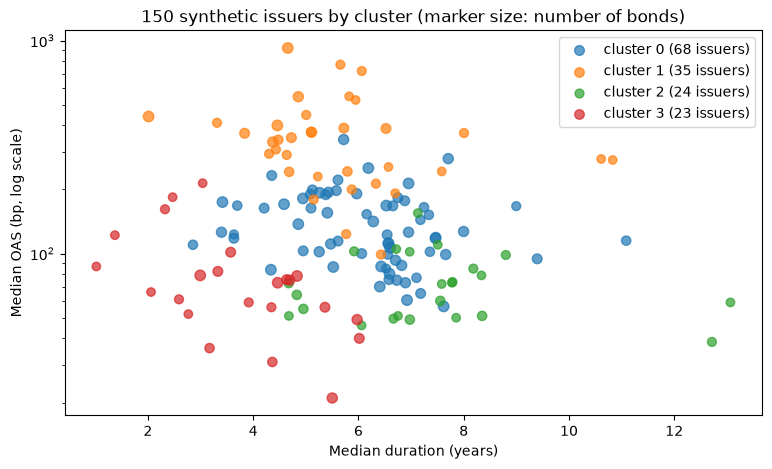

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
for k, group in issuers.groupby("cluster"):
    ax.scatter(group["median_duration"], group["median_oas"], s=25 + 4 * group["bonds"], alpha=0.7,
               label=f"cluster {k} ({len(group)} issuers)")
ax.set_yscale("log")   # a log scale for spreads, as the clusters used log OAS
ax.set_title("150 synthetic issuers by cluster (marker size: number of bonds)")
ax.set_xlabel("Median duration (years)")
ax.set_ylabel("Median OAS (bp, log scale)")
ax.legend()
plt.show()

* Two of the five columns are on the chart, and the clusters were built from all five, so some points sit among another cluster's colour: their number of bonds, amount, or rating put them there. The chart is a check on the profile's reading, not a second method.

## 13.7 K-means Against Hierarchical, on the Same Issuers

Q. Run day 12's K-means on the same scaled issuers, with k = 4, and compare the groups.

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# day 12's settings: ten starts, the course's seed; then the same numbering by size
kmeans = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_scaled)
issuers["kmeans_cluster"] = number_by_size(kmeans.labels_)

# how the issuers of each hierarchical cluster are spread over the K-means clusters
print(pd.crosstab(issuers["cluster"], issuers["kmeans_cluster"], rownames=["hierarchical"], colnames=["K-means"]))
print()
print(f"adjusted Rand index: {adjusted_rand_score(issuers['cluster'], issuers['kmeans_cluster']):.4f}")
print(f"silhouette, hierarchical: {silhouette_score(X_scaled, issuers['cluster']):.4f}; "
      f"K-means: {silhouette_score(X_scaled, issuers['kmeans_cluster']):.4f}")

K-means        0   1   2   3
hierarchical                
0             36  12   5  15
1              0  20   1  14
2              0   1  23   0
3              9   5   9   0

adjusted Rand index: 0.2552
silhouette, hierarchical: 0.2153; K-means: 0.2577


* Read the table across a row. The methods agree best on hierarchical cluster 2: 23 of its 24 issuers are in K-means cluster 2. The 35 issuers of hierarchical cluster 1, the widest spreads, are split by K-means: 20 into cluster 1 and 14 into cluster 3. The largest hierarchical cluster, 0, is spread over the four K-means clusters as 36, 12, 5, 15.
* The adjusted Rand index is 0.2552: 1 would be the same groups, and about 0 what unrelated labels would give. The two methods agree only in part. K-means' silhouette is 0.2577 against 0.2153: K-means moves its centres until every issuer sits with its nearest centre, which is close to what the silhouette rewards, while a hierarchical merge is never undone, so an issuer joined early stays where it was put.
* Neither set of groups is the true one. With silhouettes near 0.2, these issuers do not fall into clearly separated groups, so both methods impose four, each by its own rule. When two reasonable methods disagree this much, a profile is a description of one method's choice, and the text should say which.

In [30]:
# the K-means profile, in the same units, for comparison
mlkit.cluster_profile(issuers, issuers["kmeans_cluster"], profile_columns).round(2)

,count,median_oas,median_duration,bonds,amount_bn,score
cluster,,,,,,
0,45,100.0,6.40,7.0,9.75,8.0
1,38,191.0,5.71,4.0,5.57,11.0
2,38,62.5,6.62,4.0,5.12,5.0
3,29,252.0,5.11,7.0,9.50,13.0


* K-means' clusters hold 45, 38, 38, 29 issuers. Its clusters 1 and 3 both have wide median spreads (191 and 252 bp) and differ in size: 4 against 7 bonds, 5.57 against 9.50 billion dollars. Where ward kept the wide-spread issuers together, K-means cut them by size.

## 13.8 What a Profile May Say

A cluster of the synthetic issuers gets only the names the course allows:

| Allowed | Never |
| --- | --- |
| cluster, cluster 2 | never a good, bad, safe, or risky cluster |
| a group of similar rows in an invented dataset | never cheap, rich, or mispriced issuers |
| the profile: counts and medians in bp, years, billions | never a ranking of clusters or of issuers within one |
| "cluster 1 has the widest median OAS in this file" | never a signal, a target, a quality label, or a trade |

A profile describes a group: how many issuers, and their typical spread, duration, size, and rating. It does not rank the groups, and it does not say what anyone should hold. The numbering by size is there so that a cluster's number carries no meaning beyond its size.

Q. How much do the five columns overlap?

In [31]:
# correlations between the five clustering columns, over the 150 issuers
issuers[features].corr().round(2)

,median_log_oas,median_duration,bonds,amount_bn,score
median_log_oas,1.00,-0.13,0.02,0.09,0.97
median_duration,-0.13,1.00,-0.10,-0.08,-0.18
bonds,0.02,-0.10,1.00,0.82,0.03
amount_bn,0.09,-0.08,0.82,1.00,0.08
score,0.97,-0.18,0.03,0.08,1.00


* Median log OAS and rating score have a correlation of 0.97: the generator builds spreads from ratings, so the two columns carry nearly the same information, and the distance counts it twice. Number of bonds and amount outstanding have 0.82: an issuer with more bonds has more debt outstanding. So of five columns, two are mostly credit and two are mostly size.
* The generator drew each issuer's number of bonds (3 to 8) and each bond's size at random, so the size columns sort issuers by random draws. That is part of what these clusters describe, and it is worth knowing before any cluster is described: a group is only as meaningful as the columns that built it.

## Excel Side by Side

Excel has no hierarchical clustering: no linkage, no dendrogram, no cophenetic correlation. The tree is built in Python. What Excel can do is every number around it: the scaling, the distance between two issuers, and the profile. The issuer table went onto a sheet named `issuers` (A ticker, B median_log_oas, C median_duration, D bonds, E amount_bn, F score, G median_oas (bp), H cluster; rows 2 to 151), with the cluster column pasted from Python. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Scale a column | `StandardScaler().fit_transform(...)` | `=STANDARDIZE(B2,AVERAGE(B$2:B$151),STDEV.P(B$2:B$151))` in J2, filled right to N and down | equal to `StandardScaler` within 1e-9 |
| Distance, first two issuers | section 13.1 by hand | `=SQRT(SUMXMY2(J2:N2,J3:N3))` | 2.0227 |
| Distance, closest pair | `pdist` | `=SQRT(SUMXMY2(J18:N18,J137:N137))` (CLAY and WYXR) | 0.2075 |
| Issuers per cluster | `profile["count"]` | `=COUNTIF($H$2:$H$151,0)`, or a pivot table's Count | 68, 35, 24, 23 |
| Mean per cluster | `groupby("cluster").mean()` | a pivot table's Average | equal to pandas within 1e-9 |
| Median per cluster | `cluster_profile(...)` | `=MEDIAN(IF($H$2:$H$151=0,G$2:G$151))`, typed with Enter | equal to `cluster_profile` exactly |

**`STANDARDIZE` with `STDEV.P`.** As on day 12, `STANDARDIZE(x, mean, standard_dev)` with the population standard deviation reproduces `StandardScaler`; with `STDEV.S` every z-score would be smaller by the factor square root of n / (n - 1).

**The distance.** `SUMXMY2` sums the squared differences of two ranges, so `SQRT(SUMXMY2(J2:N2,J3:N3))` is section 13.1's hand calculation in one formula: rows 2 and 3 are BEZE and BEZH. Finding the closest of 11,175 pairs, and then merging, and recomputing the distances after every merge, is where Excel stops: that loop is the method, and Excel has no function for it.

**The pivot table.** Insert, PivotTable on `A1:H151`, `cluster` in Rows, then `median_oas` in Values set to Count and `median_duration` set to Average. It gave the four cluster sizes and the four average durations. A pivot table's Summarize Values By list offers Sum, Count, Average, Max, Min, and others, but no median.

**The median per cluster.** `MEDIAN(IF($H$2:$H$151=0,G$2:G$151))` keeps column G where the cluster is 0 and takes the median of what is left. In this Excel, with dynamic arrays, it works typed with Enter; in an Excel without dynamic arrays, an array formula like this is entered with Ctrl+Shift+Enter. Change the 0 to 1, 2, 3, and G to C, D, E, F, for the whole profile.

In [32]:
# Excel's medians per cluster (MEDIAN(IF(...)) for each column) and counts (COUNTIF), from the day's Excel check
excel_profile = pd.DataFrame({'median_oas': [124.5, 342.0, 68.0, 73.0], 'median_duration': [6.478, 5.228, 7.3175, 3.5725], 'bonds': [7.0, 4.0, 3.5, 5.0], 'amount_bn': [8.7, 6.05, 4.025, 7.5], 'score': [9.0, 14.0, 5.0, 6.0]}).rename_axis("cluster")
excel_profile.insert(0, "count", [68, 35, 24, 23])
same = (excel_profile.to_numpy() == profile[excel_profile.columns].to_numpy()).all()
print(f"Excel's counts and medians equal to cluster_profile, exactly: {same}")

# Excel's two distances beside Python's
excel_distances = {"BEZE and BEZH": 2.0226508452828122, "CLAY and WYXR": 0.20748853213122168}
python_distances = {"BEZE and BEZH": distances.loc["BEZE", "BEZH"], "CLAY and WYXR": distances.loc["CLAY", "WYXR"]}
side_by_side = pd.DataFrame({"Excel": excel_distances, "Python": python_distances})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side.round(4)

Excel's counts and medians equal to cluster_profile, exactly: True


,Excel,Python,within 1e-9
BEZE and BEZH,2.0227,2.0227,True
CLAY and WYXR,0.2075,0.2075,True


* The same profile and the same distances. Excel's medians equal Python's exactly: a median picks or averages actual values, with no long sum whose last digits could differ.

## Save the Day with Git

Today's work folder is new, so it gets its own repository and the module is committed. The experiment log for clustering keeps day 12's idea, one row per clustering, with today's measures: k, the number of rows, the cophenetic correlation, and the silhouette. The profile is committed beside it.

Q. Make the work folder a repository.

In [33]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [34]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_13_czwbl3do and nowhere else


Q. Tell Git which files never to track.

In [35]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Commit the module, its tests, and `.gitignore`.

In [36]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Add cluster_profile: count and medians in the data's own units, with three tests"
!git -C "{work}" log --oneline

ecf0550 Add cluster_profile: count and medians in the data's own units, with three tests

Q. Write today's clustering to `results.csv` and its profile to `profile.csv`, and commit both.

In [37]:
# one row per clustering: what was clustered, how, k, and two measures, 4 decimals
results = pd.DataFrame([{
    "model": "ward_hierarchical",
    "features": " ".join(features),
    "k": 4,
    "rows": len(issuers),
    "cophenetic": cophenetic_table["ward"],
    "silhouette": silhouette_score(X_scaled, issuers["cluster"]),
}])
results.to_csv("results.csv", index=False, float_format="%.4f")
profile.to_csv("profile.csv", float_format="%.4f")
print((work / "results.csv").read_text(encoding="utf-8"))
print((work / "profile.csv").read_text(encoding="utf-8"))

model,features,k,rows,cophenetic,silhouette
ward_hierarchical,median_log_oas median_duration bonds amount_bn score,4,150,0.5212,0.2153

cluster,count,median_oas,median_duration,bonds,amount_bn,score
0,68,124.5000,6.4780,7.0000,8.7000,9.0000
1,35,342.0000,5.2280,4.0000,6.0500,14.0000
2,24,68.0000,7.3175,3.5000,4.0250,5.0000
3,23,73.0000,3.5725,5.0000,7.5000,6.0000



In [38]:
!git -C "{work}" add results.csv profile.csv
!git -C "{work}" commit -q -m "Experiment log: ward clusters of the 150 issuers, and their profile"
!git -C "{work}" log --oneline

492bee3 Experiment log: ward clusters of the 150 issuers, and their profile


ecf0550 Add cluster_profile: count and medians in the data's own units, with three tests


Q. What did the last commit change, in one line per file?

In [39]:
# HEAD~1 is the commit before the last; --stat lists each file changed and how many lines
!git -C "{work}" diff HEAD~1 --stat

 profile.csv | 5 +++++
 results.csv | 2 ++
 2 files changed, 7 insertions(+)


* `HEAD~1` names the commit one before `HEAD`, so `git diff HEAD~1` compares the module commit with the files now. `--stat` shrinks the diff to one line per file and a count of lines added: two new files, `results.csv` with a header and one row, `profile.csv` with a header and four rows. Before reading a long diff, the stat says how big it is and where.

## Bring It Home

Add today's function and tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code. No new data file is needed: the tests read `benchmark.csv` and `ratings.csv`, which you copied on day 1.

**Step 1.** Open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the `%%writefile -a mlkit.py` cell of section 13.6, without its first line, at the end of `mlkit.py`; do the same for the `%%writefile -a test_mlkit.py` cell. Save both.

**Step 3.** Run the tests.

```powershell
& "$HOME\projects\python-fixed-income\.venv\Scripts\Activate.ps1"
python -m pytest -q test_mlkit.py
```

The last line says `53 passed`.

**Step 4.** Commit the code only, then read the size of what you committed.

```powershell
git add mlkit.py test_mlkit.py
git commit -m "Add cluster_profile: count and medians in the data's own units, with three tests"
git diff HEAD~1 --stat
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Build one row per issuer from bond data with `groupby` and `agg`, and scale it.
* Work a Euclidean distance between two issuers by hand, and match it with `pdist` and with `SQRT(SUMXMY2(...))` in Excel.
* Read a linkage matrix merge by merge, and say what single, complete, average, and ward linkage each mean by "close".
* Draw a dendrogram of 150 rows, then truncate it so it can be read, and choose a cut as a judgement with reasons.
* Measure the cophenetic correlation, and say why the highest is not automatically the best tree to cut.
* Cut a tree with `fcluster`, number the clusters by size, and profile them in the data's own units with `cluster_profile`.
* Reproduce a profile in Excel: a pivot table for counts and averages, `MEDIAN(IF(...))` for medians.
* Compare K-means and hierarchical clusters, and describe a cluster without ranking it.
* Read the size of a commit with `git diff HEAD~1 --stat`.

Tomorrow, day 14, summarises columns instead of grouping rows: PCA on the Treasury curve, level, slope, and curvature, and a t-SNE picture of the bonds.

## Exercises

The exercises use the same 150 issuers, built from the synthetic bonds: invented issuers, with spreads from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It builds the issuer table, scales it, builds the ward tree, cuts it into 4 clusters numbered by size, and defines `number_by_size` and `check`, a small function that marks your answers.

In [40]:
from scipy.cluster.hierarchy import cophenet, fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

# the 821 synthetic bonds, then one row per invented issuer, as in section 13.1
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
issuer_list = pd.read_csv("issuers.csv")
bench["log_oas"] = np.log(bench["oas"])
issuers = bench.groupby("ticker").agg(median_oas=("oas", "median"), median_log_oas=("log_oas", "median"),
                                      median_duration=("duration", "median"), bonds=("cusip", "size"),
                                      amount_bn=("amount_outstanding", "sum"))
issuers["amount_bn"] = issuers["amount_bn"] / 1e9
issuers = issuers.join(issuer_list.set_index("ticker")[["issuer", "sector", "rating"]], validate="one_to_one")
issuers["score"] = issuers["rating"].map(ratings.set_index("rating")["score"])

# the five scaled columns and the ward tree
features = ["median_log_oas", "median_duration", "bonds", "amount_bn", "score"]
profile_columns = ["median_oas", "median_duration", "bonds", "amount_bn", "score"]
X_scaled = StandardScaler().fit_transform(issuers[features])
merges = linkage(X_scaled, method="ward")


def number_by_size(labels):
    """Renumber cluster labels by size, largest first; a tie goes to the cluster holding the earlier row."""
    labels = pd.Series(labels)
    sizes = labels.value_counts()
    first_seen = {label: position for position, label in enumerate(pd.unique(labels))}
    order = sorted(sizes.index, key=lambda label: (-sizes[label], first_seen[label]))
    return labels.map({old: new for new, old in enumerate(order)}).to_numpy()


# section 13.5's four clusters
issuers["cluster"] = number_by_size(fcluster(merges, t=4, criterion="maxclust"))


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Cut the same ward tree into **5** clusters, number them by size, and profile them with `mlkit.cluster_profile` over `profile_columns`. Store the list of counts, cluster 0 first, in **ex1_counts**. Which of the four clusters split?

In [41]:
ex1_counts = ...

In [42]:
check("Exercise 1 the counts with five clusters", ex1_counts, [43, 35, 25, 24, 23])

Exercise 1 the counts with five clusters: not attempted yet


### Exercise 2

Q. Build the tree with **average** linkage instead of ward. Store its cophenetic correlation in **ex2_cophenetic**, and the sizes of its 4 clusters, largest first, as a list in **ex2_sizes**. Would you use this cut for a profile?

In [43]:
ex2_cophenetic = ...
ex2_sizes = ...

In [44]:
check("Exercise 2 the cophenetic correlation", ex2_cophenetic, 0.6316509859267213)
check("Exercise 2 the sizes", ex2_sizes, [115, 30, 3, 2])

Exercise 2 the cophenetic correlation: not attempted yet
Exercise 2 the sizes: not attempted yet


### Exercise 3

Q. Add a function to your module. `largest_cluster(labels)` returns the label of the cluster with the most rows, as an `int`; it raises `ValueError` if `labels` is empty or if two clusters tie for the most rows. Write the docstring first. Then add `test_largest_cluster_hand_values`: the labels `[2, 2, 1, 3, 2, 1]` give 2, `[0, 0, 1, 1]` raises with "tie" in the message, and `[]` raises with "empty". Run pytest, reload the module, and store `mlkit.largest_cluster(fcluster(merges, t=4, criterion="maxclust"))`, on `fcluster`'s own numbers, in **ex3_largest**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [45]:
%%writefile -a mlkit.py


# Exercise 3: write largest_cluster(labels) below this line

Appending to mlkit.py


In [46]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_largest_cluster_hand_values() below this line

Appending to test_mlkit.py


In [47]:
# run pytest, reload the module, then call your function
ex3_largest = ...

In [48]:
check("Exercise 3 largest_cluster on fcluster's labels", ex3_largest, 4)

Exercise 3 largest_cluster on fcluster's labels: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that profiles the clusters for a desk table, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Profile each cluster of issuers for a desk table: how many issuers, and the median OAS in bp and the
    median duration in years of each cluster.

    Inputs: issuers, the one-row-per-issuer table in its own units (median_oas in bp, median_duration in
    years, median_log_oas, bonds, amount_bn, score); labels, the cluster of each issuer, in the same order.
    Returns: a DataFrame indexed by cluster with columns count, median_oas_bp, median_duration_years.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a table of the right shape, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def profile_for_desk(issuers, labels):
    """Profile each cluster of issuers for a desk table: how many issuers, and the median OAS in bp and the
    median duration in years of each cluster.

    Inputs: issuers, the one-row-per-issuer table in its own units (median_oas in bp, median_duration in
    years, median_log_oas, bonds, amount_bn, score); labels, the cluster of each issuer, in the same order.
    Returns: a DataFrame indexed by cluster with columns count, median_oas_bp, median_duration_years.
    """
    features = ["median_log_oas", "median_duration", "bonds", "amount_bn", "score"]
    # scale the columns first, so every column is comparable across clusters
    scaled = pd.DataFrame(StandardScaler().fit_transform(issuers[features]), columns=features, index=issuers.index)
    grouped = scaled.groupby(np.asarray(labels))
    table = pd.DataFrame({
        "count": grouped.size(),
        "median_oas_bp": grouped["median_log_oas"].median(),
        "median_duration_years": grouped["median_duration"].median(),
    })
    table.index.name = "cluster"
    return table

Q. Before you run the next cell: will `median_oas_bp` for the cluster with the widest spreads be close to section 13.6's 342 bp?

In [50]:
profile_for_desk(issuers, issuers["cluster"]).round(4)

,count,median_oas_bp,median_duration_years
cluster,,,
0,68,-0.0780,0.3268
1,35,1.3502,-0.3221
2,24,-0.9345,0.7625
3,23,-0.8330,-1.1814


Q. Test the function against its docstring before you trust it.

In [51]:
# the test, written from the docstring before the code is trusted
desk = profile_for_desk(issuers, issuers["cluster"])
# the profile in the data's own units, from the unscaled rows
expected = mlkit.cluster_profile(issuers, issuers["cluster"], ["median_oas", "median_duration"])

# 1. the counts match
assert desk["count"].tolist() == expected["count"].tolist(), "the counts differ"
# 2. median_oas_bp is the median OAS in bp: cluster_profile's comparison, written out so the message stops in this cell
wrong = (desk["median_oas_bp"] - expected["median_oas"]).abs() >= 1e-9
assert not wrong.any(), f"median_oas_bp is not the median OAS in bp in {wrong.sum()} of {len(wrong)} clusters"
print("profile_for_desk reports the median OAS in bp")

AssertionError: median_oas_bp is not the median OAS in bp in 4 of 4 clusters

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's `median_oas_bp` column as a list, `profile_for_desk(issuers, issuers["cluster"])["median_oas_bp"].tolist()`, in **ex4_median_oas_bp**.

In [52]:
# fix the function above and run the test again, then store the answer
ex4_median_oas_bp = ...

In [53]:
check("Exercise 4 the fixed function's median OAS in bp", ex4_median_oas_bp, [124.5, 342.0, 68.0, 73.0])

Exercise 4 the fixed function's median OAS in bp: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```